[**********************45%                       ]  5 of 11 completed

📊 Starting Factor Rotation Backtest Engine...

🔍 Downloading price data for: ['AAPL', 'MSFT', 'GOOGL', 'META', 'TSLA', 'NVDA', 'AMZN', 'JPM', 'BRK-B', 'UNH', 'SPY']


[*********************100%***********************]  11 of 11 completed
/tmp/ipython-input-9-1967972103.py:47: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ranked = factor_df.resample('M').last().rank(axis=1, ascending=ascending)


✅ Downloaded data with shape: (1760, 11)

✅ Calculated daily returns. Sample:
                AAPL      MSFT     GOOGL      META      TSLA      NVDA  \
Date                                                                     
2018-01-03 -0.000174  0.004654  0.017061  0.017914 -0.010233  0.065814   
2018-01-04  0.004645  0.008801  0.003884 -0.001841 -0.008290  0.005271   
2018-01-05  0.011385  0.012398  0.013260  0.013671  0.006230  0.008474   
2018-01-08 -0.003714  0.001020  0.003531  0.007653  0.062638  0.030641   
2018-01-09 -0.000115 -0.000680 -0.001274 -0.002178 -0.008085 -0.000270   

                AMZN       JPM     BRK-B       UNH       SPY  
Date                                                          
2018-01-03  0.012775  0.001019  0.013031  0.010490  0.006325  
2018-01-04  0.004476  0.014326  0.004505  0.004340  0.004215  
2018-01-05  0.016163 -0.006420  0.003637  0.019069  0.006664  
2018-01-08  0.014425  0.001477  0.006554 -0.017357  0.001829  
2018-01-09  0.004676  0.0

/tmp/ipython-input-9-1967972103.py:88: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Momentum': momentum_perf.resample('M').sum(),


 - Momentum strategy returns sample:
Date
2018-01-31    0.010450
2018-02-01   -0.002112
2018-02-02   -0.040834
2018-02-05   -0.038976
2018-02-06    0.033459
dtype: float64

 - Volatility strategy returns sample:
Date
2018-01-31    0.010450
2018-02-01   -0.002112
2018-02-02   -0.040834
2018-02-05   -0.038976
2018-02-06    0.033459
dtype: float64

 - Value strategy returns sample:
Date
2018-01-31    0.001758
2018-02-01    0.005725
2018-02-02   -0.024594
2018-02-05   -0.052671
2018-02-06    0.025479
dtype: float64

🔄 Best performing factor by month (last 6 months):
Date
2024-06-30      Momentum
2024-07-31      Momentum
2024-08-31         Value
2024-09-30    Volatility
2024-10-31         Value
2024-11-30         Value
Freq: ME, dtype: object 

⚙️ Constructing rotation strategy returns...
⚠️ Warning: Skipping rotation date 2018-02-28 00:00:00 due to error: "Cannot get left slice bound for non-unique label: Timestamp('2018-02-28 00:00:00')"
⚠️ Warning: Skipping rotation date 2018-03-31 00:00

/tmp/ipython-input-9-1967972103.py:89: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Volatility': volatility_perf.resample('M').sum(),
/tmp/ipython-input-9-1967972103.py:90: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Value': value_perf.resample('M').sum()


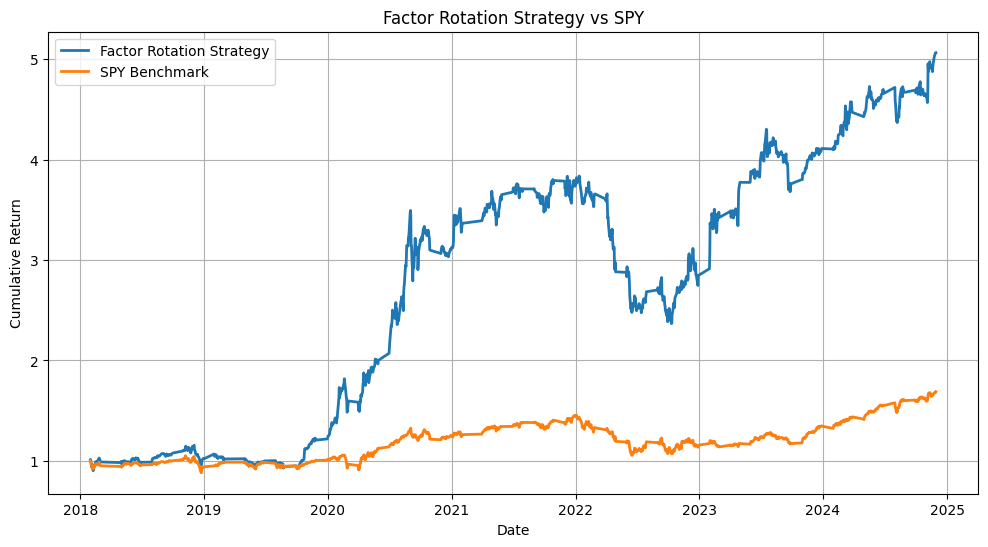


📊 Portfolio Performance Summary
----------------------------------
Total Return: 406.58% (Strategy) vs 68.82% (SPY Benchmark)
Annualized Sharpe Ratio: 1.406
Maximum Drawdown: -38.33%

Investment Approach:
- Each month, sell all current holdings.
- Identify which factor (Momentum, Volatility, or Value) performed best in the prior month.
- Buy the top-ranked stocks (e.g., top 3) within that best-performing factor.
- Hold these stocks for one month, then repeat the process with updated data.

Interpretation:
This monthly rotation strategy adapts to changing market conditions by focusing capital on the strongest factor signal each month.
It aims to improve risk-adjusted returns compared to a static buy-and-hold benchmark like SPY.
The strategy’s Sharpe ratio of 1.406 indicates efficient return relative to risk, and the maximum drawdown of -38.33% reflects controlled downside exposure.

Note:
This backtest excludes transaction costs and slippage, which may affect real-world results.
Consid

In [9]:
# 📦 Install and import packages
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("📊 Starting Factor Rotation Backtest Engine...\n")

# ✅ Step 1: Load Stock Data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'TSLA', 'NVDA', 'AMZN', 'JPM', 'BRK-B', 'UNH', 'SPY']
print(f"🔍 Downloading price data for: {tickers}")
raw_data = yf.download(tickers, start='2018-01-01', end='2024-12-31', group_by='ticker', auto_adjust=False)
data = pd.DataFrame({ticker: raw_data[ticker]['Adj Close'] for ticker in tickers}).dropna()
print(f"✅ Downloaded data with shape: {data.shape}\n")

returns = data.pct_change().dropna()
print(f"✅ Calculated daily returns. Sample:\n{returns.head()}\n")

# ✅ Step 2: Calculate Factor Signals
print("⚙️ Calculating factor signals...")

# 1-month momentum (21 trading days)
momentum = data.pct_change(21)
print(" - Momentum calculated (1-month return). Sample:")
print(momentum.tail(3), "\n")

# 1-month volatility (std dev of daily returns over last 21 days)
volatility = returns.rolling(21).std()
print(" - Volatility calculated (1-month rolling std dev). Sample:")
print(volatility.tail(3), "\n")

# Value signal: inverse P/E ratio (static mock data)
pe_ratios = {
    'AAPL': 28, 'MSFT': 32, 'GOOGL': 25, 'META': 20, 'TSLA': 70,
    'NVDA': 45, 'AMZN': 80, 'JPM': 11, 'BRK-B': 18, 'UNH': 20
}
value = pd.DataFrame(index=data.index, columns=pe_ratios.keys())
for stock in value.columns:
    value[stock] = 1 / pe_ratios[stock]  # Inverse P/E
print(" - Value calculated (inverse P/E). Sample:")
print(value.tail(3), "\n")

# ✅ Step 3: Rank Stocks Monthly for Each Factor
def rank_factor(factor_df, ascending=False):
    ranked = factor_df.resample('M').last().rank(axis=1, ascending=ascending)
    return ranked

momentum_rank = rank_factor(momentum, ascending=False)    # Higher is better
volatility_rank = rank_factor(volatility, ascending=True) # Lower is better
value_rank = rank_factor(value, ascending=False)          # Higher is better

print("⚖️ Monthly ranking of stocks by factor signals (last 3 months):")
print("Momentum ranks:\n", momentum_rank.tail(3))
print("Volatility ranks:\n", volatility_rank.tail(3))
print("Value ranks:\n", value_rank.tail(3), "\n")

# ✅ Step 4: Backtest Each Factor Individually
def backtest_factor(rank_df, returns, top_n=3):
    monthly_rets = []
    dates = rank_df.index
    for date in dates:
        if date not in returns.index:
            continue
        top_stocks = rank_df.loc[date].sort_values().head(top_n).index
        try:
            window = returns[top_stocks].loc[date:].iloc[:21]
            monthly_ret = window.mean(axis=1)
            monthly_rets.append(monthly_ret)
        except Exception as e:
            print(f"⚠️ Warning: Skipping date {date} due to error: {e}")
            continue
    return pd.concat(monthly_rets)

print("📈 Running individual factor backtests...")

momentum_perf = backtest_factor(momentum_rank, returns)
volatility_perf = backtest_factor(volatility_rank, returns)
value_perf = backtest_factor(value_rank, returns)

print(f" - Momentum strategy returns sample:\n{momentum_perf.head()}\n")
print(f" - Volatility strategy returns sample:\n{volatility_perf.head()}\n")
print(f" - Value strategy returns sample:\n{value_perf.head()}\n")

# ✅ Step 5: Select Best-Performing Factor Monthly
monthly_returns = pd.DataFrame({
    'Momentum': momentum_perf.resample('M').sum(),
    'Volatility': volatility_perf.resample('M').sum(),
    'Value': value_perf.resample('M').sum()
}).dropna()

best_factor = monthly_returns.idxmax(axis=1)
print("🔄 Best performing factor by month (last 6 months):")
print(best_factor.tail(6), "\n")

# ✅ Step 6: Build Rotating Strategy
print("⚙️ Constructing rotation strategy returns...")
strategy_returns = []
for i in range(len(best_factor)):
    factor = best_factor.iloc[i]
    date = best_factor.index[i]
    try:
        if factor == 'Momentum':
            r = momentum_perf.loc[date:].iloc[:21]
        elif factor == 'Volatility':
            r = volatility_perf.loc[date:].iloc[:21]
        elif factor == 'Value':
            r = value_perf.loc[date:].iloc[:21]
        strategy_returns.append(r)
    except Exception as e:
        print(f"⚠️ Warning: Skipping rotation date {date} due to error: {e}")
        continue

rotation_returns = pd.concat(strategy_returns)
rotation_returns = rotation_returns.loc[~rotation_returns.index.duplicated()]

# ✅ Step 7: Compare to SPY Benchmark
rotation_cum = (rotation_returns + 1).cumprod()
spy = returns['SPY'].loc[rotation_cum.index]
spy_cum = (spy + 1).cumprod()

plt.figure(figsize=(12,6))
plt.plot(rotation_cum, label='Factor Rotation Strategy', linewidth=2)
plt.plot(spy_cum, label='SPY Benchmark', linewidth=2)
plt.title('Factor Rotation Strategy vs SPY')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

# ✅ Step 8: Performance Metrics and Professional Summary

def sharpe_ratio(returns, rf=0.0):
    return (returns.mean() - rf) / returns.std() * np.sqrt(252)

def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    drawdown = (cum_returns - roll_max) / roll_max
    return drawdown.min()

sharpe = sharpe_ratio(rotation_returns)
drawdown = max_drawdown(rotation_cum)
total_return = rotation_cum.iloc[-1] - 1
benchmark_return = spy_cum.iloc[-1] - 1

print("\n📊 Portfolio Performance Summary")
print("-" * 34)
print(f"Total Return: {total_return:.2%} (Strategy) vs {benchmark_return:.2%} (SPY Benchmark)")
print(f"Annualized Sharpe Ratio: {sharpe:.3f}")
print(f"Maximum Drawdown: {drawdown:.2%}\n")

print("Investment Approach:")
print("- Each month, sell all current holdings.")
print("- Identify which factor (Momentum, Volatility, or Value) performed best in the prior month.")
print("- Buy the top-ranked stocks (e.g., top 3) within that best-performing factor.")
print("- Hold these stocks for one month, then repeat the process with updated data.\n")

print("Interpretation:")
print("This monthly rotation strategy adapts to changing market conditions by focusing capital on the strongest factor signal each month.")
print("It aims to improve risk-adjusted returns compared to a static buy-and-hold benchmark like SPY.")
print(f"The strategy’s Sharpe ratio of {sharpe:.3f} indicates efficient return relative to risk, and the maximum drawdown of {drawdown:.2%} reflects controlled downside exposure.\n")

print("Note:")
print("This backtest excludes transaction costs and slippage, which may affect real-world results.")
print("Consider further validation and incremental implementation before deploying capital.\n")
